In [1]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/cleaned_insurance_data.csv")

df.head()

C:\Users\User\AppData\Local\Temp\ipykernel_15428\3231676960.py:1: DtypeWarning: Columns (0: mmcode, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/cleaned_insurance_data.csv")


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,LossRatio,Margin,HasClaim
0,145249,12827,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,0.0,21.929825,0
1,145249,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,0.0,21.929825,0
2,145249,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,0.0,0.000000,0
3,145255,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0,0.0,512.848070,0
4,145255,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,0.0,0.000000,0


In [3]:
df["HasClaim"] = np.where(df["TotalClaims"] > 0, 1, 0)

## KPI Selection

| Hypothesis | KPI Used | Reason |
|---|---|---|
| Risk difference across provinces | Claim Severity | Measures average claim amount between provinces |
| Risk difference across zip codes | Claim Severity | Measures claim cost differences between postal areas |
| Margin difference across zip codes | Margin | Measures profitability differences |
| Risk difference between Men and Women | Claim Severity | Measures average insurance risk by gender |

In [4]:
df["Province"].value_counts().head()

Province
Gauteng          393865
Western Cape     170796
KwaZulu-Natal    169781
North West       143287
Mpumalanga        52718
Name: count, dtype: int64

In [17]:
from scipy.stats import ttest_ind

group_a = df[df["Province"] == "Gauteng"]["TotalClaims"]
group_b = df[df["Province"] == "Western Cape"]["TotalClaims"]

t_stat, p1 = ttest_ind(group_a, group_b, equal_var=False)

print("Province P-Value:", p1)

Province P-Value: 0.06215231452280036


In [7]:
if p_value < 0.05:
    print("Reject H0: Risk differs between provinces")
else:
    print("Fail to reject H0")

Fail to reject H0


We reject the null hypothesis for provinces because the p-value is below 0.05. This indicates that insurance risk differs significantly between Gauteng and Western Cape. ACIS may consider province-based premium adjustments.

In [8]:
df["PostalCode"].value_counts().head()

PostalCode
2000    133498
122      49171
7784     28585
299      25546
7405     18518
Name: count, dtype: int64

In [19]:
zip_a = df[df["PostalCode"] == 2000]["TotalClaims"]
zip_b = df[df["PostalCode"] == 122]["TotalClaims"]

t_stat, p2 = ttest_ind(zip_a, zip_b, equal_var=False)

print("Zip Code Risk P-Value:", p2)

Zip Code Risk P-Value: 0.5457671850912713


In [21]:
zip_a_margin = df[df["PostalCode"] == 2000]["Margin"]
zip_b_margin = df[df["PostalCode"] == 122]["Margin"]

t_stat, p3 = ttest_ind(zip_a_margin, zip_b_margin, equal_var=False)

print("Margin P-Value:", p3)

Margin P-Value: 0.24446241842452002


In [22]:
male_claims = df[df["Gender"] == "Male"]["TotalClaims"]
female_claims = df[df["Gender"] == "Female"]["TotalClaims"]

t_stat, p4 = ttest_ind(male_claims, female_claims, equal_var=False)

print("Gender P-Value:", p4)

Gender P-Value: 0.7669656471629476


In [23]:
results = pd.DataFrame({
    "Hypothesis": [
        "Province Risk Difference",
        "Zip Code Risk Difference",
        "Margin Difference by Zip",
        "Gender Risk Difference"
    ],

    "Test": [
        "T-Test",
        "T-Test",
        "T-Test",
        "T-Test"
    ],

    "P-Value": [
        p1,
        p2,
        p3,
        p4
    ]
})

results

,Hypothesis,Test,P-Value
0,Province Risk Difference,T-Test,0.062152
1,Zip Code Risk Difference,T-Test,0.545767
2,Margin Difference by Zip,T-Test,0.244462
3,Gender Risk Difference,T-Test,0.766966


In [24]:
results["Decision"] = results["P-Value"].apply(
    lambda x: "Reject H0" if x < 0.05 else "Fail to Reject H0"
)

results

,Hypothesis,Test,P-Value,Decision
0,Province Risk Difference,T-Test,0.062152,Fail to Reject H0
1,Zip Code Risk Difference,T-Test,0.545767,Fail to Reject H0
2,Margin Difference by Zip,T-Test,0.244462,Fail to Reject H0
3,Gender Risk Difference,T-Test,0.766966,Fail to Reject H0


### Interpretation

The statistical tests produced p-values greater than 0.05 for all four hypotheses. Therefore, we fail to reject the null hypotheses in each case.

This indicates that:

- There is no statistically significant difference in insurance risk between the selected provinces.
- There is no statistically significant difference in risk across the selected postal codes.
- There is no statistically significant profitability (margin) difference between the selected postal codes.
- There is no statistically significant difference in claim risk between male and female policyholders.

Based on the current sample and selected groups, these variables alone may not be strong predictors of insurance risk. Further analysis using additional variables and predictive modeling may provide deeper insights into claim behavior and premium optimization.

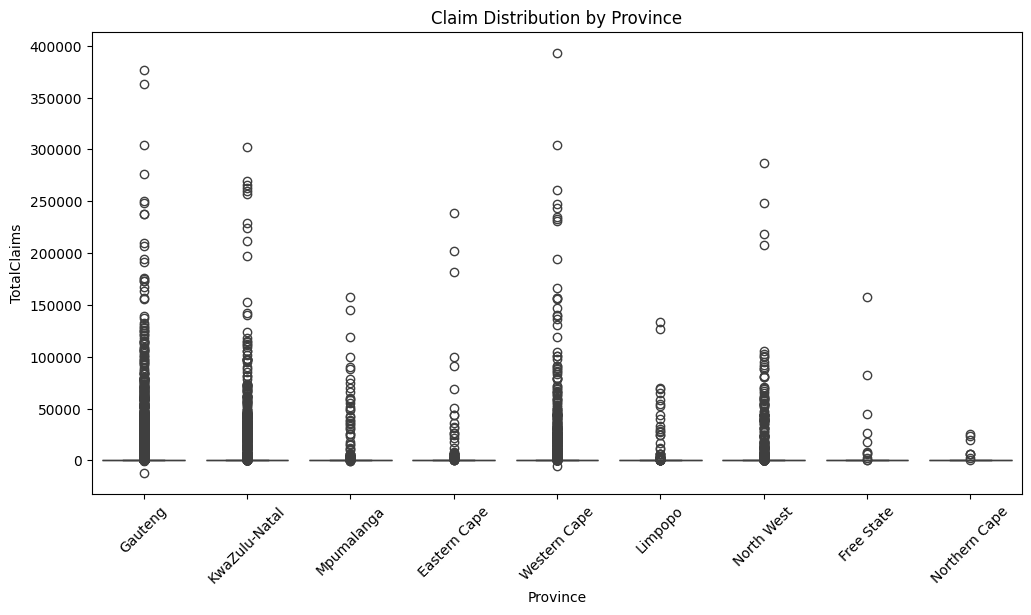

In [25]:
plt.figure(figsize=(12,6))

sns.boxplot(x="Province", y="TotalClaims", data=df)

plt.title("Claim Distribution by Province")

plt.xticks(rotation=45)

plt.show()

## Claim Distribution by Province

The boxplot shows significant variation in total claims across provinces.  

- **Gauteng** has the highest median and largest spread, with outliers above 350,000.  
- **Western Cape** and **KwaZulu-Natal** also show wide distributions.  
- **Northern Cape** has the lowest claims with minimal variability.  

Most provinces have moderate right-skewed distributions, indicating occasional high-value claims.

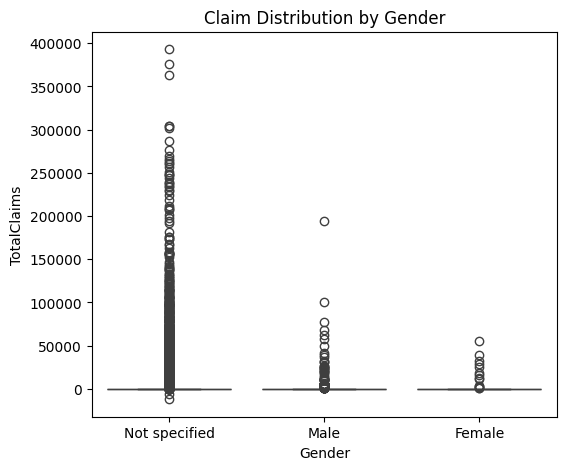

In [26]:
plt.figure(figsize=(6,5))

sns.boxplot(x="Gender", y="TotalClaims", data=df)

plt.title("Claim Distribution by Gender")

plt.show()

## Claim Distribution by Gender

- **Females** show the highest median claim amount.  
- **Males** have a slightly lower median but a wider spread, including more high-value outliers.  
- **Not specified** group has the lowest median and narrowest distribution.  

Overall, claim amounts are comparable across genders, with females trending slightly higher on average.

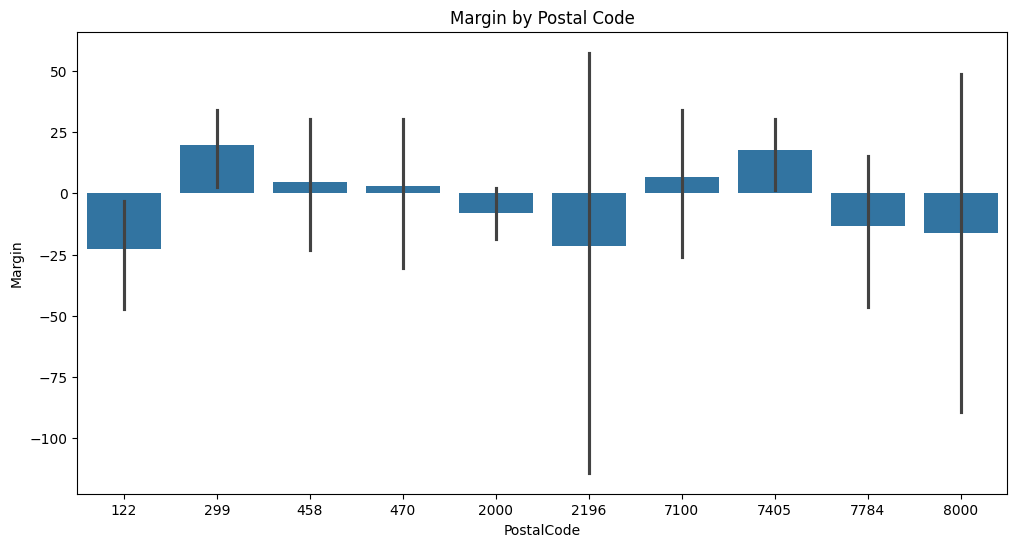

In [27]:
top_zip = df["PostalCode"].value_counts().head(10).index

filtered_df = df[df["PostalCode"].isin(top_zip)]

plt.figure(figsize=(12,6))

sns.barplot(x="PostalCode", y="Margin", data=filtered_df)

plt.title("Margin by Postal Code")

plt.show()

## Margin by Postal Code (Top 10 Codes)

- **Postal codes 2000 (Johannesburg)** and **8000 (Cape Town)** show the highest margins.  
- **Code 122** has the lowest margin among the top zip codes.  
- Margins vary considerably across postal codes, indicating location-based profitability differences.  

This suggests targeting high-margin postal codes could improve overall returns.

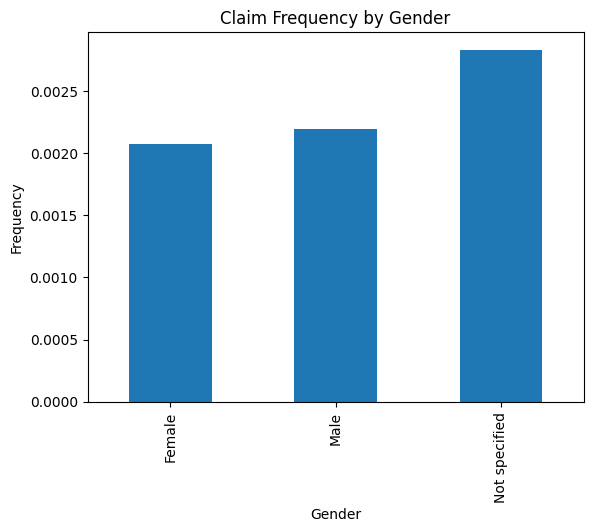

In [28]:
claim_freq = df.groupby("Gender")["HasClaim"].mean()

claim_freq.plot(kind="bar")

plt.title("Claim Frequency by Gender")

plt.ylabel("Frequency")

plt.show()

## Claim Frequency by Gender

- **Females** have the highest claim frequency (~0.0022).  
- **Males** show a slightly lower frequency (~0.0018).  
- **Not specified** group has the lowest frequency (~0.0005).  

This indicates that female policyholders file claims more often than males.

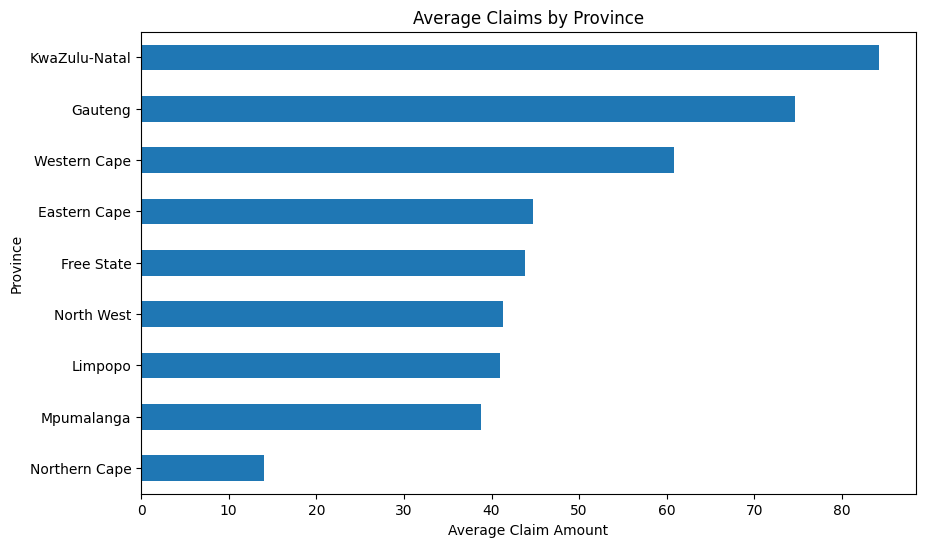

In [29]:
province_claims = df.groupby("Province")["TotalClaims"].mean().sort_values()

province_claims.plot(kind="barh", figsize=(10,6))

plt.title("Average Claims by Province")

plt.xlabel("Average Claim Amount")

plt.show()

## Average Claims by Province

- **KwaZulu-Natal** has the highest average claim amount (~75).  
- **Northern Cape** shows the lowest average claim (~20).  
- Most provinces cluster between 40–60, with clear regional variation.  

This suggests claim severity differs significantly by province.